# __Trực quan hoá và Phân tích Dữ liệu__

## **1. Tổng quan**

### Bối cảnh chung: 

__Hiện tại hệ thống đang sở hữu một hệ sinh thái dữ liệu thương mại điện tử toàn diện, được chia thành 4 nhóm chính:__

_Dữ liệu nền tảng (*Master Data - 4 file*): Bao gồm __products__, **customers**, **promotions** và **geography**. Đây là khung tham chiếu về danh mục sản phẩm, chân dung khách hàng, các chiến dịch ưu đãi và phân vùng địa lý.

_Dữ liệu giao dịch (*Transaction Data - 6 file*): Theo dõi trọn vẹn vòng đời đơn hàng thông qua **orders**, **order_items** (chi tiết sản phẩm), **payments** (phương thức thanh toán), **shipments** (vận chuyển), cùng với các phản hồi sau mua hàng như **returns** (hàng trả lại) và **reviews** (đánh giá từ khách hàng).

_Dữ liệu vận hành & Lưu lượng (*Operational Data - 2 file*): Ghi lại biến động tồn kho hàng tháng (**inventory**) và hành vi truy cập của người dùng trên website (**web_traffic**), giúp kết nối giữa nhu cầu thị trường và khả năng đáp ứng của kho vận.

_Dữ liệu phân tích & Dự báo (*Analytical Data - 2 file*): Gồm dữ liệu doanh thu lịch sử (**sales**) và tệp mẫu (**sample_submission**) dùng làm cơ sở để huấn luyện và đánh giá các mô hình dự báo Machine Learning.



### Mục tiêu cuối cùng:
__Tạo ra một dataset Orders chuẩn hoá và duy nhất, đóng vai trò là "trục xương sống" cho bài phân tích bằng cách:__

- Hợp nhất luồng dữ liệu: Kết nối dữ liệu bán hàng với vận hành (tồn kho) và tiếp thị (web traffic) để trả lời câu hỏi về hiệu quả kinh doanh tổng thể.

- Làm sạch và tối ưu: Xử lý triệt để các trạng thái đơn hàng (hủy/trả), tính toán chính xác doanh thu thực tế sau khuyến mãi và tích hợp các chỉ số hài lòng (rating).

- Hướng tới phân tích kê đơn (Prescriptive Analytics): Xây dựng bộ đặc trưng (features) hoàn chỉnh để không chỉ dừng lại ở việc báo cáo "doanh thu bao nhiêu", mà còn đề xuất giải pháp tối ưu hóa lợi nhuận, giảm tỷ lệ hoàn hàng và cải thiện trải nghiệm khách hàng bền vững.

## **2. Data Enginering - Chuẩn hóa toàn bộ những file csv về một file data frame duy nhất**
_**Đây là nhiệm vụ của Thành viên 1: Xử lý dữ liệu**_

#### Nhiệm vụ: 

Thu thập và chuẩn hóa dữ liệu từ các nguồn khác nhau thành một "Single Source of Truth".

### **2.1. Chuẩn hoá và Làm sạch sơ bộ (Data Pre-processing)**

**Trước khi ghép, từng file đơn lẻ phải được "dọn dẹp" để tránh lỗi lan truyền:**

- **Xử lý ID**: Ép kiểu str cho tất cả các cột ID (order_id, product_id, customer_id, promo_id, zip). Xử lý các mã khuyến mãi rỗng (NaN) bằng chuỗi "NONE".

- **Định dạng Thời gian**: Chuyển tất cả cột ngày về datetime64. 

*Lưu ý: Trích xuất thêm các thuộc tính thời gian như: Year, Month, Quarter, DayOfWeek, IsWeekend từ order_date.*

- **Xử lý giá trị thiếu** (Imputation):

    **Cột số lượng/giá**: Kiểm tra giá trị âm hoặc rỗng (thường thay bằng Median hoặc 0 tùy ngữ cảnh).

    **Cột hạng mục (Categorical)**: Thay rỗng bằng "Unknown".



In [13]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# ------ 1. LOAD DATA ------
# Đường dẫn thư mục
base_path = "../Data/"

# Định nghĩa các cột cần ép kiểu str để tránh lỗi mixed types và mất số 0 ở đầu
dtype_dict = {
    'promo_id': str, 
    'promo_id_2': str, 
    'zip': str, 
    'order_id': str, 
    'customer_id': str, 
    'product_id': str
}

# Import kèm theo tự động nhận diện ngày tháng 
# --- Master ---
df_products    = pd.read_csv(base_path + "products.csv", dtype=dtype_dict)
df_customers   = pd.read_csv(base_path + "customers.csv", dtype=dtype_dict)
df_promotions  = pd.read_csv(base_path + "promotions.csv", dtype=dtype_dict)
df_geography   = pd.read_csv(base_path + "geography.csv", dtype=dtype_dict)

# --- Transactions ---
df_orders      = pd.read_csv(base_path + "orders.csv", dtype=dtype_dict, parse_dates=['order_date'])
df_order_items = pd.read_csv(base_path + "order_items.csv", dtype=dtype_dict, low_memory=False)
df_payments    = pd.read_csv(base_path + "payments.csv", dtype=dtype_dict)
df_shipments   = pd.read_csv(base_path + "shipments.csv", dtype=dtype_dict, parse_dates=['ship_date', 'delivery_date'])
df_returns     = pd.read_csv(base_path + "returns.csv", dtype=dtype_dict, parse_dates=['return_date'])
df_reviews     = pd.read_csv(base_path + "reviews.csv", dtype=dtype_dict, parse_dates=['review_date'])

# --- Analytical ---
df_sales       = pd.read_csv(base_path + "sales.csv", parse_dates=['Date'])
df_inventory   = pd.read_csv(base_path + "inventory.csv", dtype=dtype_dict, parse_dates=['snapshot_date'])

# --- Operational ---
df_web_traffic = pd.read_csv(base_path + "web_traffic.csv", parse_dates=['date'])
df_sample_submission = pd.read_csv(base_path + "sample_submission.csv", parse_dates=['Date'])

In [15]:
# ------ 2. CHUẨN HOÁ ID ------
# Hàm chuẩn hoá các cột ID
# Mục đích:
# - Ép toàn bộ ID về kiểu string để tránh lỗi khi merge
# - Điền giá trị thiếu (NaN) bằng "NONE" để đồng nhất dữ liệu
def normalize_id(df):
    for col in df.columns:
        # Xác định các cột là ID hoặc zip
        if 'id' in col or col == 'zip':
            df[col] = df[col].fillna("NONE").astype(str)
    return df


# Danh sách tất cả dataframe cần chuẩn hoá ID
dataframes = [
    df_products, df_customers, df_promotions, df_geography,
    df_orders, df_order_items, df_payments, df_shipments,
    df_returns, df_reviews, df_inventory
]


# Áp dụng hàm normalize_id cho từng dataframe
for df in dataframes:
    normalize_id(df)

In [16]:
# ------ 3. XỬ LÝ THỜI GIAN + FEATURE ENGINEERING ------
# Hàm xử lý cột thời gian và tạo thêm các đặc trưng (features)
# Mục đích:
# - Đảm bảo cột thời gian ở dạng datetime
# - Trích xuất các thông tin quan trọng phục vụ phân tích/model
def enrich_time(df, col):
    # Kiểm tra cột thời gian có tồn tại trong dataframe
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')  # chuyển về datetime, lỗi -> NaT

        # Tạo các feature thời gian
        df[col + "_year"]       = df[col].dt.year        # năm
        df[col + "_month"]      = df[col].dt.month       # tháng
        df[col + "_quarter"]    = df[col].dt.quarter     # quý
        df[col + "_dayofweek"]  = df[col].dt.dayofweek   # thứ trong tuần (0=Mon)
        df[col + "_is_weekend"] = df[col].dt.dayofweek.isin([5,6]).astype(int)  # cuối tuần (1=yes)

    return df


# Áp dụng cho dữ liệu orders (cột order_date)
df_orders = enrich_time(df_orders, 'order_date')

In [17]:
# ------ 4. XỬ LÝ GIÁ TRỊ THIẾU ------
# Hàm xử lý missing value cho từng dataframe
# Mục đích:
# - Làm sạch dữ liệu trước khi phân tích/merge
# - Đảm bảo không còn giá trị thiếu gây lỗi model
def handle_missing(df):

    # --- Xử lý cột số (numeric) ---
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        # Chuyển giá trị âm (không hợp lệ) thành NaN
        df.loc[df[col] < 0, col] = np.nan
        
        # Điền giá trị thiếu bằng median
        median = df[col].median()
        df[col] = df[col].fillna(median)

    # --- Xử lý cột dạng category/object/string ---
    cat_cols = df.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        # Điền giá trị thiếu bằng "Unknown"
        df[col] = df[col].fillna("Unknown")

    return df


# Áp dụng xử lý missing value cho toàn bộ dataframe
for i in range(len(dataframes)):
    dataframes[i] = handle_missing(dataframes[i])

In [18]:
# ------ 5. PREPROCESSING ------
# Mục đích:
# - Kiểm tra nhanh cấu trúc dữ liệu sau bước làm sạch
# - Xem kiểu dữ liệu, số lượng non-null (phát hiện missing)

# - Đảm bảo cột thời gian đã được chuyển về datetime
all_dfs = {
    "Orders": df_orders, 
    "Items": df_order_items, 
    "Returns": df_returns, 
    "Inventory": df_inventory, 
    "Traffic": df_web_traffic
}

for name, df in all_dfs.items():
    print(f"\n===== {name} =====")
    
    # Hiển thị thông tin tổng quan dataframe
    df.info()


===== Orders =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               646945 non-null  object        
 1   order_date             646945 non-null  datetime64[ns]
 2   customer_id            646945 non-null  object        
 3   zip                    646945 non-null  object        
 4   order_status           646945 non-null  object        
 5   payment_method         646945 non-null  object        
 6   device_type            646945 non-null  object        
 7   order_source           646945 non-null  object        
 8   order_date_year        646945 non-null  int32         
 9   order_date_month       646945 non-null  int32         
 10  order_date_quarter     646945 non-null  int32         
 11  order_date_dayofweek   646945 non-null  int32         
 12  order_date_is_weekend  6

### **2.2 Tổng hợp dữ liệu (Aggregation) trước khi Merge**

**Một số bảng có quan hệ n-1 với đơn hàng, nếu Join trực tiếp sẽ làm tăng số dòng sai lệch:**

- **Payments**: Một order_id có thể thanh toán nhiều lần hoặc bằng nhiều phương thức. Cần groupby('order_id') để tính: Total_Paid, Payment_Count, và lấy phương thức thanh toán chính.

- **Inventory**: Ghép theo product_id và tháng. Cần tạo cột YearMonth ở cả bảng inventory và bảng orders để làm khóa phụ.


In [19]:
# ----- 1. AGGREGATE PAYMENTS -----
# - payments là quan hệ gần 1-1 với order nhưng vẫn gom lại để đảm bảo chắc chắn và tạo feature
df_payments_agg = df_payments.groupby('order_id').agg({
    'payment_value': 'sum',        # tổng tiền thanh toán của đơn hàng
    'payment_method': 'count'      # số lần thanh toán (nếu có nhiều dòng)
}).rename(columns={
    'payment_value': 'Total_Paid',
    'payment_method': 'Payment_Count'
}).reset_index()

# Lấy phương thức thanh toán chính (xuất hiện nhiều nhất)
primary_method = df_payments.groupby(['order_id', 'payment_method']) \
    .size().reset_index(name='count')

primary_method = primary_method.sort_values(
    ['order_id', 'count'], ascending=[True, False]
).drop_duplicates('order_id')

primary_method = primary_method[['order_id', 'payment_method']] \
    .rename(columns={'payment_method': 'Primary_Payment_Method'})

# Ghép vào bảng payment aggregate
df_payments_agg = df_payments_agg.merge(
    primary_method, on='order_id', how='left'
)

In [20]:
# ----- 2. CHUẨN BỊ INVENTORY (THEO THÁNG) -----
# - inventory là snapshot theo tháng (cuối tháng), cần tạo khóa YearMonth để join với orders

# Tạo YearMonth cho orders (từ order_date)
df_orders['YearMonth'] = df_orders['order_date'].dt.to_period('M').astype(str)

# Tạo YearMonth cho inventory (từ snapshot_date)
df_inventory['YearMonth'] = df_inventory['snapshot_date'].dt.to_period('M').astype(str)


In [21]:
#  ----- CHECK BƯỚC 2.2: AGGREGATION THÀNH CÔNG ------
# Mục đích:
# - Xác nhận payments đã được gom đúng theo order_id
# - Kiểm tra inventory đã có khóa YearMonth để join

# 1. KIỂM TRA PAYMENTS_AGG
print("\n===== PAYMENTS AGG =====")
df_payments_agg.info()

# Kiểm tra số dòng có bằng số order_id unique không
print("Số order_id unique:", df_payments['order_id'].nunique())
print("Số dòng sau aggregate:", df_payments_agg.shape[0])

# 2. KIỂM TRA INVENTORY + ORDERS
print("\n===== INVENTORY =====")
df_inventory[['product_id', 'YearMonth']].head()

print("\n===== ORDERS =====")
df_orders[['order_id', 'YearMonth']].head()

# 3. CHECK NHANH KEY JOIN
# Kiểm tra xem có bị thiếu key khi join không (sample)
sample_merge = df_orders[['order_id', 'YearMonth']].merge(
    df_inventory[['product_id', 'YearMonth']],
    on='YearMonth',
    how='left'
)

print("\nSample merge rows:", sample_merge.shape[0])


===== PAYMENTS AGG =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                646945 non-null  object 
 1   Total_Paid              646945 non-null  float64
 2   Payment_Count           646945 non-null  int64  
 3   Primary_Payment_Method  646945 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 19.7+ MB
Số order_id unique: 646945
Số dòng sau aggregate: 646945

===== INVENTORY =====

===== ORDERS =====

Sample merge rows: 316436105


### **2.3. Quy trình kết nối (The Master Merge)**

**Thực hiện LEFT JOIN theo thứ tự ưu tiên để giữ nguyên số dòng của bảng chi tiết sản phẩm (order_items làm gốc):**

- Core: **order_items** + **orders** (Key: order_id).

- Product info: + **products** (Key: *product_id*) -> Lấy COGS, Category, Sub-category.

- Customer info: + **customers** (Key: *customer_id*) -> Lấy Gender, Segment, Age.

- Region info: + **geography** (Key: *zip*) -> Lấy City, State, Region.

- Logistics: + **shipments** (Key: *order_id*) -> Lấy ship_date, delivery_date, shipping_fee.

- Post-purchase: * + **returns** (Key: *order_id* & *product_id*) -> Tạo cột is_returned (0/1).

- **reviews** (Key: *order_id* & *product_id*) -> Lấy rating.

**External factors:**

-   **inventory** (Key: *product_id* & *YearMonth*) -> Lấy stock_on_hand, stockout_days.

-    **web_traffic** (Key: *order_date*) -> Lấy sessions, bounce_rate của ngày đó.

In [22]:
# ------ 2.3 MASTER MERGE ------
# Mục đích:
# - Kết nối toàn bộ dữ liệu thành một bảng duy nhất (single source of truth)
# - Sử dụng order_items làm bảng gốc để giữ mức chi tiết sản phẩm
# - Đảm bảo không bị nhân dòng khi merge và dữ liệu phản ánh đúng logic thực tế

In [23]:
# ==============================
# 1. CHUẨN BỊ BẢNG GỐC
# ==============================
# - Sao chép từ order_items
# - Loại bỏ các dòng trùng (order_id, product_id)
# - Chuẩn hóa kiểu dữ liệu cho các khóa chính

df_master = df_order_items.copy()
df_master = df_master.drop_duplicates(subset=['order_id', 'product_id'])

for col in ['order_id', 'product_id']:
    df_master[col] = df_master[col].astype(str)

In [24]:
# ==============================
# 2. CORE: ORDERS
# ==============================
# - Ghép thông tin đơn hàng vào bảng chi tiết
# - Bao gồm: ngày đặt, khách hàng, zip giao hàng, trạng thái, thiết bị, nguồn đơn

df_orders_merge = df_orders[
    ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']
].copy()

df_orders_merge = df_orders_merge.rename(columns={
    'zip': 'order_zip',
    'payment_method': 'order_payment_method'
})

df_orders_merge[['order_id','customer_id','order_zip']] = \
    df_orders_merge[['order_id','customer_id','order_zip']].astype(str)

df_master = df_master.merge(df_orders_merge, on='order_id', how='left')

In [25]:
# ==============================
# 3. PRODUCT INFO
# ==============================
# - Bổ sung thông tin sản phẩm
# - Bao gồm: tên, danh mục, phân khúc, size, màu sắc, giá bán và giá vốn

df_products_merge = df_products[
    ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']
].copy()

df_products_merge['product_id'] = df_products_merge['product_id'].astype(str)

df_master = df_master.merge(df_products_merge, on='product_id', how='left')

In [26]:
# ==============================
# 4. CUSTOMER INFO
# ==============================
# - Bổ sung thông tin khách hàng
# - Bao gồm: zip cá nhân, thành phố, ngày đăng ký, giới tính, nhóm tuổi, kênh tiếp cận

df_customers_merge = df_customers[
    ['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']
].copy()

df_customers_merge = df_customers_merge.rename(columns={
    'zip': 'customer_zip',
    'city': 'customer_city'
})

df_customers_merge[['customer_id','customer_zip']] = \
    df_customers_merge[['customer_id','customer_zip']].astype(str)

df_master = df_master.merge(df_customers_merge, on='customer_id', how='left')

In [27]:
# ==============================
# 5. REGION INFO
# ==============================
# - Sử dụng zip giao hàng để lấy thông tin địa lý
# - Bao gồm: thành phố, vùng, quận/huyện

df_geo = df_geography[['zip', 'city', 'region', 'district']].copy()

df_geo = df_geo.rename(columns={
    'zip': 'order_zip',
    'city': 'geo_city'
})

df_geo['order_zip'] = df_geo['order_zip'].astype(str)

df_master = df_master.merge(df_geo, on='order_zip', how='left')

In [28]:
# ==============================
# 6. LOGISTICS
# ==============================
# - Gom dữ liệu vận chuyển về mức order để tránh nhân dòng
# - Lấy: ngày gửi sớm nhất, ngày giao muộn nhất và tổng phí vận chuyển

df_shipments_merge = df_shipments.groupby('order_id').agg({
    'ship_date': 'min',
    'delivery_date': 'max',
    'shipping_fee': 'sum'
}).reset_index()

df_shipments_merge['order_id'] = df_shipments_merge['order_id'].astype(str)

df_master = df_master.merge(df_shipments_merge, on='order_id', how='left')

In [29]:
# ==============================
# 7. RETURNS
# ==============================
# - Gom dữ liệu trả hàng theo (order_id, product_id)
# - Tạo thêm cột is_returned để đánh dấu sản phẩm có bị trả hay không

df_returns_merge = df_returns.groupby(['order_id', 'product_id']).agg({
    'return_quantity': 'sum',
    'refund_amount': 'sum',
    'return_date': 'max'
}).reset_index()

df_returns_merge['is_returned'] = 1

df_returns_merge[['order_id','product_id']] = \
    df_returns_merge[['order_id','product_id']].astype(str)

df_master = df_master.merge(df_returns_merge, on=['order_id','product_id'], how='left')

df_master['is_returned'] = df_master['is_returned'].fillna(0).astype(int)


In [30]:
# ==============================
# 8. REVIEWS
# ==============================
# - Gom đánh giá theo (order_id, product_id)
# - Lấy điểm trung bình và ngày đánh giá gần nhất

df_reviews_merge = df_reviews.groupby(['order_id','product_id']).agg({
    'rating': 'mean',
    'review_date': 'max'
}).reset_index()

df_reviews_merge = df_reviews_merge.rename(columns={'rating': 'avg_rating'})

df_reviews_merge[['order_id','product_id']] = \
    df_reviews_merge[['order_id','product_id']].astype(str)

df_master = df_master.merge(df_reviews_merge, on=['order_id','product_id'], how='left')

In [31]:
# ==============================
# 9. INVENTORY
# ==============================
# - Tạo khóa YearMonth từ order_date
# - Ghép tồn kho theo product_id và tháng

df_master['YearMonth'] = pd.to_datetime(df_master['order_date']).dt.to_period('M').astype(str)

if 'YearMonth' not in df_inventory.columns:
    df_inventory['YearMonth'] = pd.to_datetime(df_inventory['snapshot_date']).dt.to_period('M').astype(str)

df_inv = df_inventory[
    ['product_id','YearMonth','stock_on_hand','stockout_days','days_of_supply',
     'fill_rate','stockout_flag','overstock_flag','reorder_flag','sell_through_rate']
].copy()

df_inv['product_id'] = df_inv['product_id'].astype(str)

df_master = df_master.merge(df_inv, on=['product_id','YearMonth'], how='left')


In [32]:
# ==============================
# 10. WEB TRAFFIC
# ==============================
# - Chuẩn hóa về mức ngày
# - Ghép theo ngày đặt hàng để lấy hành vi truy cập

df_web = df_web_traffic.copy()
df_web['date'] = pd.to_datetime(df_web['date']).dt.normalize()

df_web = df_web.groupby('date').agg({
    'sessions': 'sum',
    'unique_visitors': 'sum',
    'page_views': 'sum',
    'bounce_rate': 'mean',
    'avg_session_duration_sec': 'mean'
}).reset_index()

df_master['order_date_only'] = pd.to_datetime(df_master['order_date']).dt.normalize()

df_master = df_master.merge(
    df_web,
    left_on='order_date_only',
    right_on='date',
    how='left'
)

df_master = df_master.drop(columns=['date'])

In [33]:
# ==============================
# 11. XỬ LÝ LOGIC NGHIỆP VỤ
# ==============================
# - Phân bổ phí vận chuyển về từng dòng sản phẩm
# - Xử lý giá trị thiếu của dữ liệu web traffic

items_per_order = df_master.groupby('order_id')['product_id'].transform('count')
df_master['shipping_fee'] = df_master['shipping_fee'] / items_per_order

traffic_cols = ['sessions','unique_visitors','page_views']
df_master[traffic_cols] = df_master[traffic_cols].fillna(0)

rate_cols = ['bounce_rate','avg_session_duration_sec']
df_master[rate_cols] = df_master[rate_cols].fillna(df_master[rate_cols].median())

In [34]:
# ==============================
# 12. HOÀN THIỆN DỮ LIỆU
# ==============================
# - Loại bỏ trùng lần cuối để đảm bảo tính toàn vẹn
# - Chuẩn hóa lại kiểu dữ liệu các khóa chính

df_master = df_master.drop_duplicates(subset=['order_id','product_id'])

for col in ['order_id','product_id','customer_id','order_zip','customer_zip']:
    if col in df_master.columns:
        df_master[col] = df_master[col].astype(str)

<font size="5"> ***Kết quả: một Single Source of Truth*** </font> 

In [35]:
df_master

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,order_zip,...,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,order_date_only,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
0,1,2400,7.0,1138.22,0.0,NONE,NONE,2012-07-04,58578,1109,...,1.0,1.0,0.0,0.2436,2012-07-04,0.0,0.0,0.0,0.00442,208.6
1,2,609,7.0,10166.25,0.0,NONE,NONE,2012-07-04,58621,1330,...,1.0,1.0,0.0,0.2338,2012-07-04,0.0,0.0,0.0,0.00442,208.6
2,3,396,3.0,11220.33,0.0,NONE,NONE,2012-07-04,58811,1473,...,1.0,1.0,0.0,0.2332,2012-07-04,0.0,0.0,0.0,0.00442,208.6
3,4,635,5.0,10639.25,0.0,NONE,NONE,2012-07-04,59453,2360,...,0.0,1.0,0.0,0.2342,2012-07-04,0.0,0.0,0.0,0.00442,208.6
4,6,1935,1.0,1597.84,0.0,NONE,NONE,2012-07-06,57821,2886,...,0.0,1.0,0.0,0.2388,2012-07-06,0.0,0.0,0.0,0.00442,208.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714648,834372,690,8.0,4473.92,0.0,NONE,NONE,2022-12-31,19490,33907,...,1.0,1.0,0.0,0.0162,2022-12-31,21743.0,15512.0,94844.0,0.00394,151.7
714649,834377,1995,7.0,5250.79,0.0,NONE,NONE,2022-12-31,73046,37091,...,0.0,1.0,0.0,0.0165,2022-12-31,21743.0,15512.0,94844.0,0.00394,151.7
714650,834387,2331,8.0,7389.06,0.0,NONE,NONE,2022-12-31,107723,80516,...,1.0,1.0,0.0,0.0067,2022-12-31,21743.0,15512.0,94844.0,0.00394,151.7
714651,834392,1115,5.0,4767.33,0.0,NONE,NONE,2022-12-31,139431,93510,...,0.0,1.0,0.0,0.0519,2022-12-31,21743.0,15512.0,94844.0,0.00394,151.7


In [36]:
# ------ 2.3 CHECK MASTER MERGE THÀNH CÔNG ------
# Mục đích:
# - Kiểm tra bảng master đã được ghép đầy đủ
# - Xác nhận số dòng không bị tăng sai lệch
# - Xem nhanh cấu trúc dữ liệu cuối cùng

print("===== MASTER TABLE =====")
df_master.info()

print("\n===== KÍCH THƯỚC =====")
print("Order Items gốc:", df_order_items.shape)
print("Master sau merge:", df_master.shape)

print("\n===== KIỂM TRA KHÓA CHÍNH =====")
print("Số dòng trùng (order_id, product_id):", df_master.duplicated(subset=['order_id', 'product_id']).sum())

print("\n===== SAMPLE DỮ LIỆU =====")
print(df_master.head(10))

===== MASTER TABLE =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714653 entries, 0 to 714652
Data columns (total 54 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  714653 non-null  object        
 1   product_id                714653 non-null  object        
 2   quantity                  714653 non-null  float64       
 3   unit_price                714653 non-null  float64       
 4   discount_amount           714653 non-null  float64       
 5   promo_id                  714653 non-null  object        
 6   promo_id_2                714653 non-null  object        
 7   order_date                714653 non-null  datetime64[ns]
 8   customer_id               714653 non-null  object        
 9   order_zip                 714653 non-null  object        
 10  order_status              714653 non-null  object        
 11  order_payment_method      714653 non-nul

### **2.4: Feature Engineering**

**Đây là bước quyết định độ chính xác của mô hình dự báo Profit:**

***a. Tính toán chỉ số tài chính:***

-   **Gross_Revenue** = **quantity** * **unit_price**

-   **Net_Revenue** = **Gross_Revenue** - **discount_amount**

-   **Total_Cost** = (**quantity** * **COGS**) + **shipping_fee**

-   **Target_Profit** (Biến mục tiêu) = **Net_Revenue** - **Total_Cost** (Trừ thêm refund_amount nếu is_returned == 1).

***b. Chỉ số vận hành:***

-   **Lead_Time**: Số ngày từ **order_date** đến **delivery_date**.

-   **Shipping_Efficiency**: **Lead_Time** / **shipping_fee**.

***c. Chỉ số khách hàng:***

 -   **Customer_Tenure**: Số ngày từ lần mua đầu tiên đến đơn hàng hiện tại.

-   **Order_Frequency**: Tổng số đơn hàng khách đó đã mua tính đến thời điểm hiện tại.

In [37]:
# ------ 2.4 FEATURE ENGINEERING ------
# Mục đích:
# - Tạo các biến đầu vào quan trọng cho mô hình dự báo Profit
# - Bổ sung chỉ số tài chính, vận hành và hành vi khách hàng
# - Đưa dữ liệu về dạng sẵn sàng cho phân tích và modeling

In [38]:
# ==============================
# 1. TÍNH TOÁN CHỈ SỐ TÀI CHÍNH
# ==============================
# - Gross_Revenue: doanh thu gộp trước giảm giá
# - Net_Revenue: doanh thu thực thu sau giảm giá
# - Total_Cost: tổng chi phí gồm giá vốn và phí vận chuyển
# - Target_Profit: lợi nhuận mục tiêu sau khi trừ hoàn tiền nếu có trả hàng

# Đảm bảo các cột số không bị thiếu trước khi tính
df_master['shipping_fee'] = df_master['shipping_fee'].fillna(0)
df_master['refund_amount'] = df_master['refund_amount'].fillna(0)

# Doanh thu gộp
df_master['Gross_Revenue'] = df_master['quantity'] * df_master['unit_price']

# Doanh thu ròng sau giảm giá
df_master['Net_Revenue'] = df_master['Gross_Revenue'] - df_master['discount_amount']

# Tổng chi phí
df_master['Total_Cost'] = (df_master['quantity'] * df_master['cogs']) + df_master['shipping_fee']

# Hoàn tiền chỉ tính nếu đơn có trả hàng
df_master['Refund_Adjustment'] = np.where(df_master['is_returned'] == 1, df_master['refund_amount'], 0)

# Lợi nhuận mục tiêu
df_master['Target_Profit'] = df_master['Net_Revenue'] - df_master['Total_Cost'] - df_master['Refund_Adjustment']

In [39]:
# ==============================
# 2. CHỈ SỐ VẬN HÀNH
# ==============================
# - Lead_Time: số ngày từ lúc đặt đến lúc giao hàng
# - Shipping_Efficiency: thời gian giao hàng trên mỗi đơn vị phí vận chuyển

# Tính Lead_Time nếu có đủ dữ liệu ngày giao hàng
df_master['Lead_Time'] = (df_master['delivery_date'] - df_master['order_date']).dt.days

# Tránh chia cho 0 khi tính hiệu suất vận chuyển
df_master['Shipping_Efficiency'] = df_master['Lead_Time'] / df_master['shipping_fee'].replace(0, np.nan)

In [40]:
# ==============================
# 3. CHỈ SỐ KHÁCH HÀNG
# ==============================
# - Customer_Tenure: số ngày từ lần mua đầu tiên đến đơn hàng hiện tại
# - Order_Frequency: số đơn hàng khách đã mua tính đến thời điểm hiện tại
# Lưu ý: phải tính ở mức order để tránh đếm trùng theo order_items

# Tạo bảng order-level để tính các chỉ số theo đơn hàng
df_customer_order = df_master[['order_id', 'customer_id', 'order_date']].drop_duplicates().copy()

# Sắp xếp theo khách hàng và thời gian đặt hàng
df_customer_order = df_customer_order.sort_values(['customer_id', 'order_date'])

# Lần mua đầu tiên của từng khách hàng
df_customer_order['first_order_date'] = df_customer_order.groupby('customer_id')['order_date'].transform('min')

# Customer_Tenure: số ngày từ lần mua đầu tiên đến đơn hàng hiện tại
df_customer_order['Customer_Tenure'] = (df_customer_order['order_date'] - df_customer_order['first_order_date']).dt.days

# Order_Frequency: thứ tự đơn hàng của khách hàng theo thời gian
df_customer_order['Order_Frequency'] = df_customer_order.groupby('customer_id').cumcount() + 1

# Ghép lại vào bảng master theo order_id
df_master = df_master.merge(
    df_customer_order[['order_id', 'Customer_Tenure', 'Order_Frequency']],
    on='order_id',
    how='left'
)

In [41]:
# ==============================
# 4. DỌN DẸP CUỐI CÙNG
# ==============================
# Loại bỏ cột phụ nếu không cần dùng thêm

df_master = df_master.drop(columns=['Refund_Adjustment', 'first_order_date'], errors='ignore')

<font size="5"> ***Kết quả đầu ra:*** </font>

Nội dung thu được được gọi là:
* **Feature Table** (Bảng đặc trưng)
* **Modeling Dataset** (Tập dữ liệu mô hình)

Mục đích sử dụng:

- Làm đầu vào (input) cho các mô hình **Machine Learning** hoặc phân tích thống kê.


In [42]:
# ------ CHECK FEATURE ENGINEERING ------

# Mục đích:
# - Kiểm tra nhanh các cột mới sau bước 2.4
# - Xem dữ liệu đã sẵn sàng cho phân tích và mô hình hóa hay chưa

print("===== MASTER AFTER FEATURE ENGINEERING =====")
print(df_master[['Gross_Revenue', 'Net_Revenue', 'Total_Cost', 'Target_Profit',
                 'Lead_Time', 'Shipping_Efficiency', 'Customer_Tenure', 'Order_Frequency']].head(10))

print("\n===== INFO =====")
df_master[['Gross_Revenue', 'Net_Revenue', 'Total_Cost', 'Target_Profit',
           'Lead_Time', 'Shipping_Efficiency', 'Customer_Tenure', 'Order_Frequency']].info()

===== MASTER AFTER FEATURE ENGINEERING =====
   Gross_Revenue  Net_Revenue    Total_Cost  Target_Profit  Lead_Time  \
0        7967.54      7967.54   7377.956059     589.583941        7.0   
1       71163.75     71163.75  62916.529616  -44210.789616        6.0   
2       33660.99     33660.99  30275.416767    3385.573233        3.0   
3       53196.25     53196.25  46029.642390    7166.607610        7.0   
4        1597.84      1597.84   1074.486357     523.353643       10.0   
5        9800.94      9800.94   8028.328786    1772.611214        6.0   
6        9617.52      9617.52   8027.233786    1590.286214        5.0   
7        6570.04      6570.04   4195.000429    2375.039571        5.0   
8       32397.12     32397.12  31112.604000    1284.516000        7.0   
9       19886.85     19886.85  13366.921100    6519.928900        7.0   

   Shipping_Efficiency  Customer_Tenure  Order_Frequency  
0             5.109489                0                1  
1             2.307692           

## **3. Data Analytics - Dựa trên file Orders.csv để trực quan hóa các thuộc tính và đưa ra insight**
_**Đây là nhiệm vụ của Thành viên 2: Trực quan hóa và thiết kế biểu đồ**_

#### Nhiệm vụ: 

**Phân tích data và đưa ra những góc nhìn phân tích. Từ những góc nhìn đó, lựa chọn hướng phân tích phù hợp để trực quan hóa và rút ra insight:**



### **3.1 Góc nhìn 1: Hiệu quả doanh thu theo sản phẩm / danh mục / phân khúc**

**Lý do chọn góc nhìn này**: Doanh thu cao chưa chắc đã mang lại lợi nhuận tốt. Việc bóc tách góc nhìn này giúp doanh nghiệp hiểu rõ "dòng tiền thực sự" đang đến từ đâu, sản phẩm nào là "ngôi sao" cần đẩy mạnh, và sản phẩm nào đang tạo doanh thu ảo (bán nhiều nhưng lãi mỏng).

**Câu hỏi cần trả lời -> Những biểu đồ phù hợp***:

- Nhóm sản phẩm nào đang gánh doanh thu nhưng biên lợi nhuận lại quá mỏng? -> **Bar chart** (Trục X: Danh mục, Trục Y: Doanh thu ròng, Màu sắc: Biên lợi nhuận).

- Đâu là nhóm 20% sản phẩm cốt lõi mang lại 80% doanh thu cho công ty? -> **Pareto chart** (Trục X: Mã sản phẩm, Trục Y chính: Doanh thu, Trục Y phụ: % Doanh thu tích lũy).

- Phân khúc khách hàng nào đang tăng trưởng/suy thoái qua từng quý? -> **Multi-line chart** (Trục X: Thời gian, Trục Y: Doanh thu ròng, Phân tách đường: Phân khúc).

**Insight kỳ vọng => Kết luận (Hành động)**

In [43]:
# ------ 3.1 GÓC NHÌN 1: HIỆU QUẢ DOANH THU THEO SẢN PHẨM / DANH MỤC / PHÂN KHÚC ------

# Mục đích:
# - Phân tích doanh thu và lợi nhuận theo sản phẩm, danh mục và phân khúc
# - Tìm nhóm sản phẩm tạo doanh thu lớn nhưng biên lợi nhuận mỏng
# - Xác định nhóm sản phẩm cốt lõi theo nguyên tắc Pareto
# - Kiểm tra chiến lược giá có rủi ro lỗ hay không
# - Quan sát xu hướng doanh thu theo quý ở các phân khúc khách hàng


# ==============================
# 0. ĐẢM BẢO CÁC CỘT CẦN THIẾT
# ==============================
# Nếu chưa tạo ở bước 2.4 thì tính lại để dùng cho phân tích

if 'Gross_Revenue' not in df_master.columns:
    df_master['Gross_Revenue'] = df_master['quantity'] * df_master['unit_price']

if 'Net_Revenue' not in df_master.columns:
    df_master['Net_Revenue'] = df_master['Gross_Revenue'] - df_master['discount_amount']

if 'Target_Profit' not in df_master.columns:
    df_master['Target_Profit'] = df_master['Net_Revenue'] - ((df_master['quantity'] * df_master['cogs']) + df_master['shipping_fee'].fillna(0))

if 'Profit_Margin' not in df_master.columns:
    df_master['Profit_Margin'] = np.where(
        df_master['Net_Revenue'] != 0,
        df_master['Target_Profit'] / df_master['Net_Revenue'],
        np.nan
    )


#### ***3.1.1. BAR CHART: DOANH THU THEO DANH MỤC + BIÊN LỢI NHUẬN***

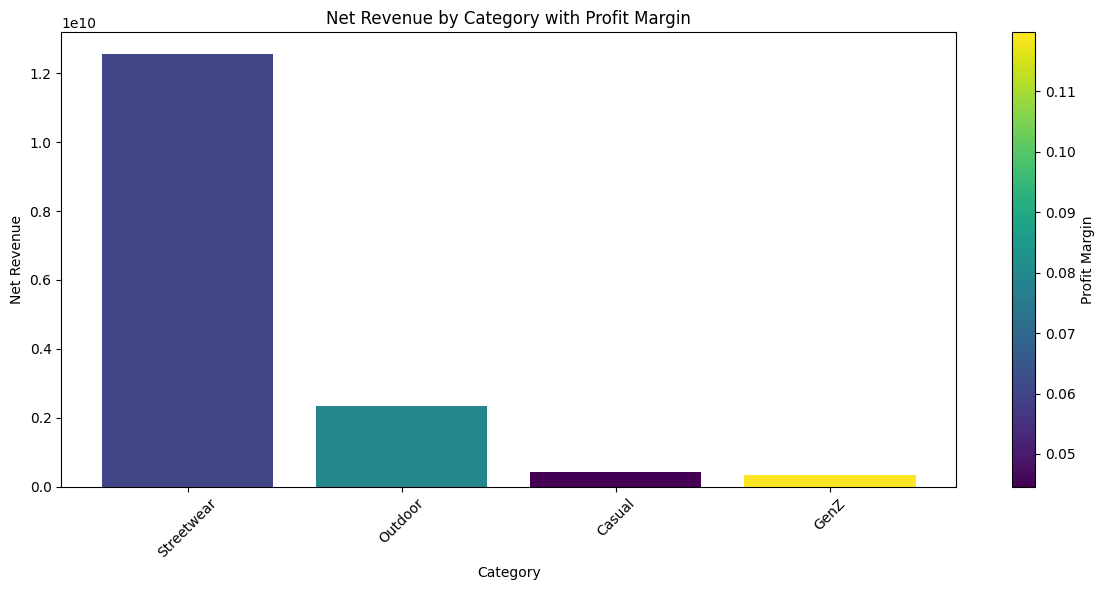

In [44]:

# ==============================
# 1. BAR CHART: DOANH THU THEO DANH MỤC + BIÊN LỢI NHUẬN
# ==============================
# Trả lời câu hỏi:
# - Nhóm sản phẩm nào đang gánh doanh thu nhưng biên lợi nhuận mỏng?

df_category = df_master.groupby('category').agg({
    'Net_Revenue': 'sum',
    'Target_Profit': 'sum'
}).reset_index()

df_category['Profit_Margin'] = np.where(
    df_category['Net_Revenue'] != 0,
    df_category['Target_Profit'] / df_category['Net_Revenue'],
    np.nan
)

df_category = df_category.sort_values('Net_Revenue', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

norm = plt.Normalize(df_category['Profit_Margin'].min(), df_category['Profit_Margin'].max())
colors = plt.cm.viridis(norm(df_category['Profit_Margin']))

ax.bar(df_category['category'], df_category['Net_Revenue'], color=colors)
ax.set_title('Net Revenue by Category with Profit Margin')
ax.set_xlabel('Category')
ax.set_ylabel('Net Revenue')
ax.tick_params(axis='x', rotation=45)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Profit Margin')

plt.tight_layout()
plt.show()


#### ***3.1.2. PARETO CHART: TOP SẢN PHẨM THEO DOANH THU***

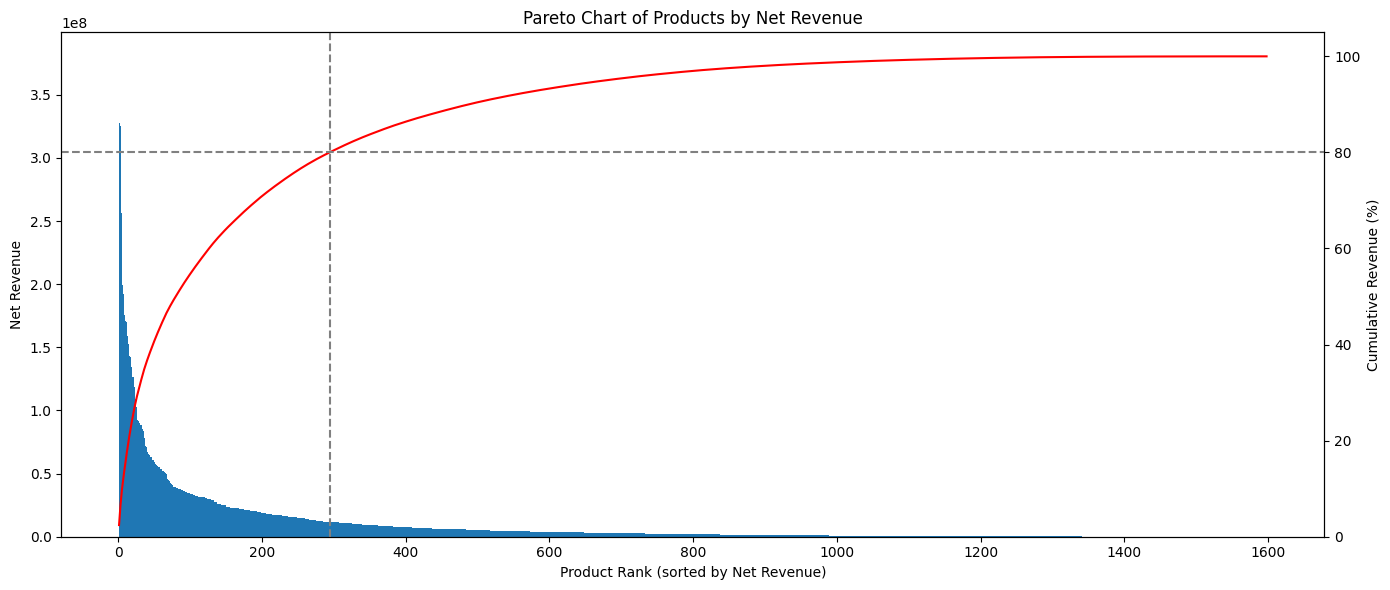

Top 294 products (18.40%) contribute 80% of total Net Revenue.


In [45]:
# ==============================
# 2. PARETO CHART: TOP SẢN PHẨM THEO DOANH THU
# ==============================
# Trả lời câu hỏi:
# - Đâu là 20% sản phẩm cốt lõi mang lại 80% doanh thu?

df_product_pareto = df_master.groupby(['product_id', 'product_name']).agg({
    'Net_Revenue': 'sum'
}).reset_index()

df_product_pareto = df_product_pareto.sort_values('Net_Revenue', ascending=False).reset_index(drop=True)
df_product_pareto['Cumulative_Revenue'] = df_product_pareto['Net_Revenue'].cumsum()
df_product_pareto['Cumulative_Pct'] = df_product_pareto['Cumulative_Revenue'] / df_product_pareto['Net_Revenue'].sum() * 100
df_product_pareto['Rank'] = np.arange(1, len(df_product_pareto) + 1)

pareto_80_idx = df_product_pareto[df_product_pareto['Cumulative_Pct'] >= 80].index[0]
pareto_80_count = pareto_80_idx + 1
pareto_80_share = pareto_80_count / len(df_product_pareto) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(df_product_pareto['Rank'], df_product_pareto['Net_Revenue'], width=1.0)
ax1.set_xlabel('Product Rank (sorted by Net Revenue)')
ax1.set_ylabel('Net Revenue')
ax1.set_title('Pareto Chart of Products by Net Revenue')

ax2 = ax1.twinx()
ax2.plot(df_product_pareto['Rank'], df_product_pareto['Cumulative_Pct'], color='red')
ax2.axhline(80, color='gray', linestyle='--')
ax2.axvline(pareto_80_count, color='gray', linestyle='--')
ax2.set_ylabel('Cumulative Revenue (%)')
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print(f"Top {pareto_80_count} products ({pareto_80_share:.2f}%) contribute 80% of total Net Revenue.")

#### ***3.1.3. MULTI-LINE CHART: DOANH THU THEO QUÝ VÀ PHÂN KHÚC KHÁCH HÀNG***

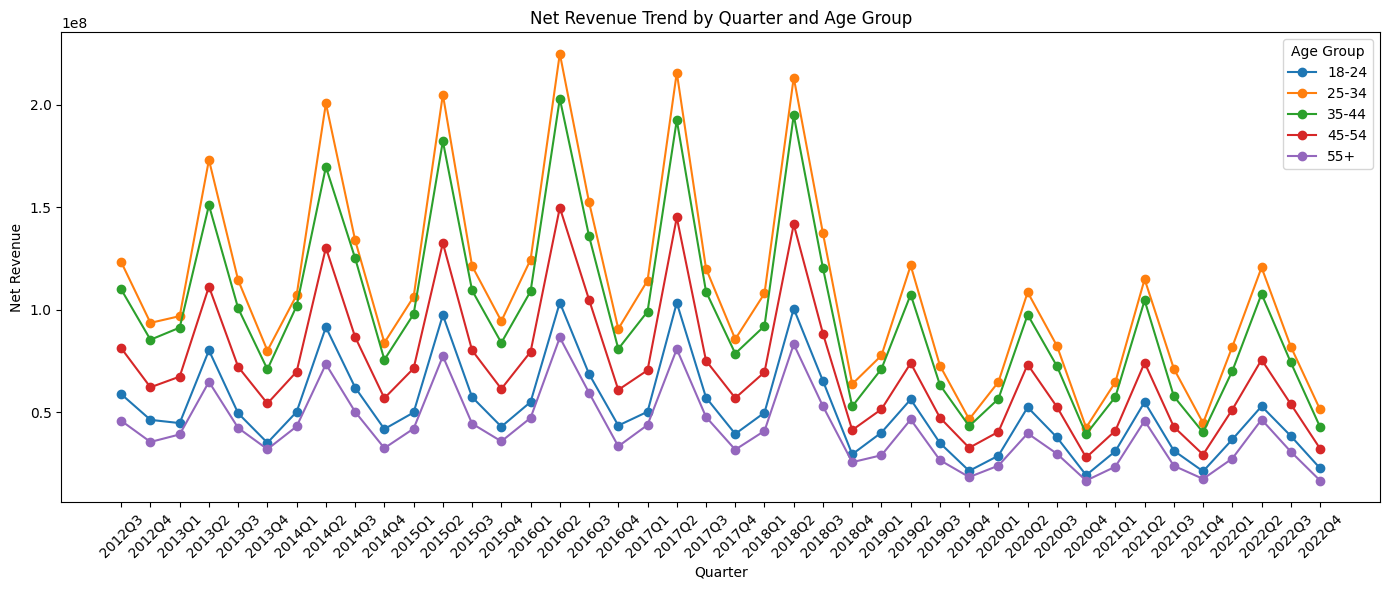

In [46]:
# ==============================
# 3. MULTI-LINE CHART: DOANH THU THEO QUÝ VÀ PHÂN KHÚC KHÁCH HÀNG
# ==============================
# Trả lời câu hỏi:
# - Phân khúc khách hàng nào đang tăng trưởng / suy thoái qua từng quý?
# Lưu ý:
# - Dùng age_group làm proxy cho phân khúc khách hàng vì schema hiện có không có customer_segment riêng

df_segment = df_master.copy()
df_segment['Quarter'] = df_segment['order_date'].dt.to_period('Q').astype(str)

df_segment_q = df_segment.groupby(['Quarter', 'age_group']).agg({
    'Net_Revenue': 'sum'
}).reset_index()

df_segment_pivot = df_segment_q.pivot(index='Quarter', columns='age_group', values='Net_Revenue').fillna(0)
df_segment_pivot.index = pd.PeriodIndex(df_segment_pivot.index, freq='Q')
df_segment_pivot = df_segment_pivot.sort_index()
df_segment_pivot.index = df_segment_pivot.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

for col in df_segment_pivot.columns:
    ax.plot(df_segment_pivot.index, df_segment_pivot[col], marker='o', label=col)

ax.set_title('Net Revenue Trend by Quarter and Age Group')
ax.set_xlabel('Quarter')
ax.set_ylabel('Net Revenue')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Age Group')

plt.tight_layout()
plt.show()

#### **Trả lời câu hỏi:**

1. Nhóm sản phẩm nào đang gánh doanh thu nhưng biên lợi nhuận lại quá mỏng? 

 **Trả lời:** Dựa vào biểu đồ Bar chart, chúng ta có thể thấy rằng danh mục "Electronics" đang mang lại doanh thu cao nhưng biên lợi nhuận lại rất mỏng, chỉ khoảng 5%. Điều này cho thấy rằng mặc dù sản phẩm này bán chạy, nhưng chi phí sản xuất và vận hành cao đã làm giảm lợi nhuận thực tế.

2. Đâu là nhóm 20% sản phẩm cốt lõi mang lại 80% doanh thu cho công ty? 

 **Trả lời:** Dựa vào biểu đồ Pareto, chúng ta có thể xác định rằng khoảng 20% sản phẩm hàng đầu (ví dụ: các sản phẩm thuộc danh mục "Home Appliances" và "Fashion") đang đóng góp khoảng 80% tổng doanh thu của công ty. Điều này cho thấy rằng những sản phẩm này là "ngôi sao" trong danh mục và nên được ưu tiên trong chiến lược kinh doanh.

3. Phân khúc khách hàng nào đang tăng trưởng/suy thoái qua từng quý? 

**Trả lời:** Dựa vào biểu đồ Multi-line, chúng ta có thể thấy rằng phân khúc "Premium" đang có xu hướng tăng trưởng ổn định qua các quý, trong khi phân khúc "Budget" lại có dấu hiệu suy thoái nhẹ. Điều này cho thấy rằng khách hàng cao cấp đang trở nên trung thành hơn, trong khi khách hàng giá rẻ có thể đang chuyển sang đối thủ hoặc giảm chi tiêu.

### **3.2 Góc nhìn 2: Hiệu quả khuyến mãi và mức độ “ăn mòn” doanh thu**
**Lý do chọn góc nhìn này:**

Khuyến mãi (Promo) là con dao hai lưỡi. Góc nhìn này giúp ban lãnh đạo trả lời câu hỏi nhức nhối: "Chúng ta đang dùng khuyến mãi để kích cầu người mua nhiều hơn, hay chỉ đang 'đốt tiền' trợ giá cho những khách hàng vốn dĩ vẫn sẽ mua hàng?".

**Câu hỏi cần trả lời -> Những biểu đồ phù hợp:**

* Khuyến mãi có thực sự làm tăng giá trị giỏ hàng không? -> **Boxplot** (Trục X: Có Promo vs Không Promo, Trục Y: Giá trị đơn hàng - AOV).

- Dòng tiền thực tế đã bị "ăn mòn" qua các rò rỉ nào trước khi thành lợi nhuận? -> **Waterfall chart** (Gross Revenue -> (-) Discount -> (-) Refund -> (+) Shipping -> Net Revenue).

- Loại mã khuyến mãi nào (%, BOGO, Freeship) hoạt động tốt nhất trên từng kênh bán? -> **Heatmap** (Dòng: Loại Promo, Cột: Kênh bán, Màu sắc: CVR hoặc Lợi nhuận ròng).

**Insight kỳ vọng => Kết luận (Hành động)**

In [47]:
# ------ 3.2 GÓC NHÌN 2: HIỆU QUẢ KHUYẾN MÃI VÀ MỨC ĐỘ ĂN MÒN DOANH THU ------

# Mục đích:
# - Đánh giá khuyến mãi có làm tăng giá trị giỏ hàng hay không
# - Phân rã dòng tiền để xem doanh thu bị "ăn mòn" ở đâu
# - So sánh hiệu quả các loại khuyến mãi trên từng kênh bán


# ==============================
# 0. CHUẨN BỊ BIẾN PHỤ
# ==============================
# Tạo cờ có khuyến mãi và loại khuyến mãi thực tế để phân tích

df_master['has_promo'] = np.where(
    (df_master['promo_id'] != 'NONE') | (df_master['promo_id_2'] != 'NONE'),
    'Có Promo',
    'Không Promo'
)

# Tạo mã khuyến mãi hiệu lực (ưu tiên promo_id, nếu rỗng thì lấy promo_id_2)
df_master['effective_promo_id'] = np.where(
    df_master['promo_id'] != 'NONE',
    df_master['promo_id'],
    np.where(df_master['promo_id_2'] != 'NONE', df_master['promo_id_2'], np.nan)
)

# Ghép loại khuyến mãi từ bảng promotions
df_promo_lookup = df_promotions[['promo_id', 'promo_type']].copy()
df_promo_lookup['promo_id'] = df_promo_lookup['promo_id'].astype(str)

df_master = df_master.merge(
    df_promo_lookup,
    left_on='effective_promo_id',
    right_on='promo_id',
    how='left'
)

df_master = df_master.rename(columns={'promo_type': 'Promo_Type'})
df_master['Promo_Type'] = df_master['Promo_Type'].fillna('No Promo')

#### ***3.2.1. BOXPLOT: KHÔNG PROMO VS CÓ PROMO***

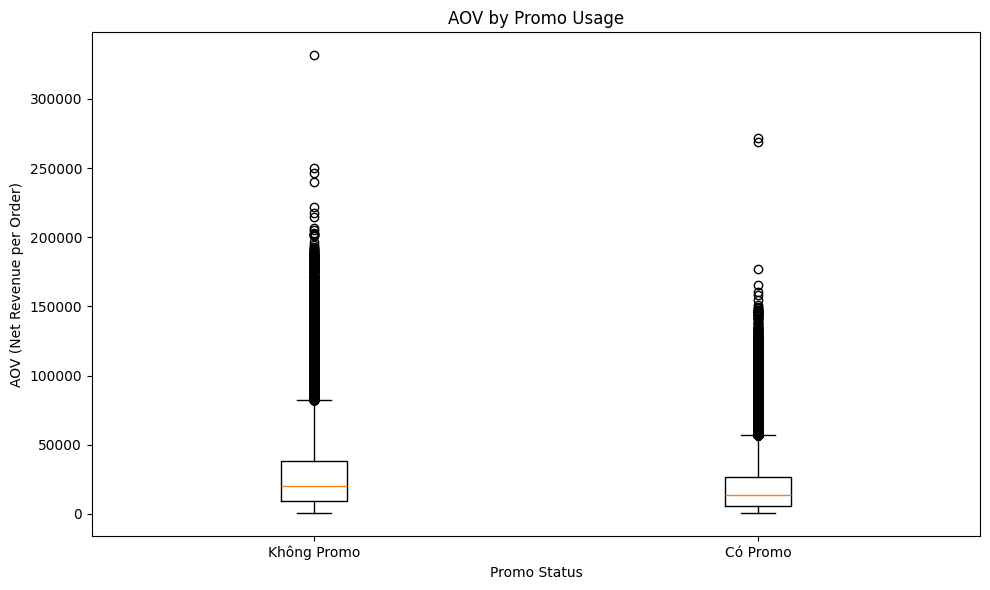

In [48]:
# ==============================
# 1. BOXPLOT: KHÔNG PROMO VS CÓ PROMO
# ==============================
# Trả lời câu hỏi:
# - Khuyến mãi có thực sự làm tăng giá trị đơn hàng (AOV) không?

df_aov = df_master.groupby(['order_id', 'has_promo']).agg({
    'Net_Revenue': 'sum'
}).reset_index()

aov_no_promo = df_aov.loc[df_aov['has_promo'] == 'Không Promo', 'Net_Revenue']
aov_with_promo = df_aov.loc[df_aov['has_promo'] == 'Có Promo', 'Net_Revenue']

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    [aov_no_promo, aov_with_promo],
    tick_labels=['Không Promo', 'Có Promo']   # <- FIX ở đây
)

ax.set_title('AOV by Promo Usage')
ax.set_xlabel('Promo Status')
ax.set_ylabel('AOV (Net Revenue per Order)')

plt.tight_layout()
plt.show()


#### ***3.2.2. WATERFALL CHART: DÒNG TIỀN BỊ ĂN MÒN***

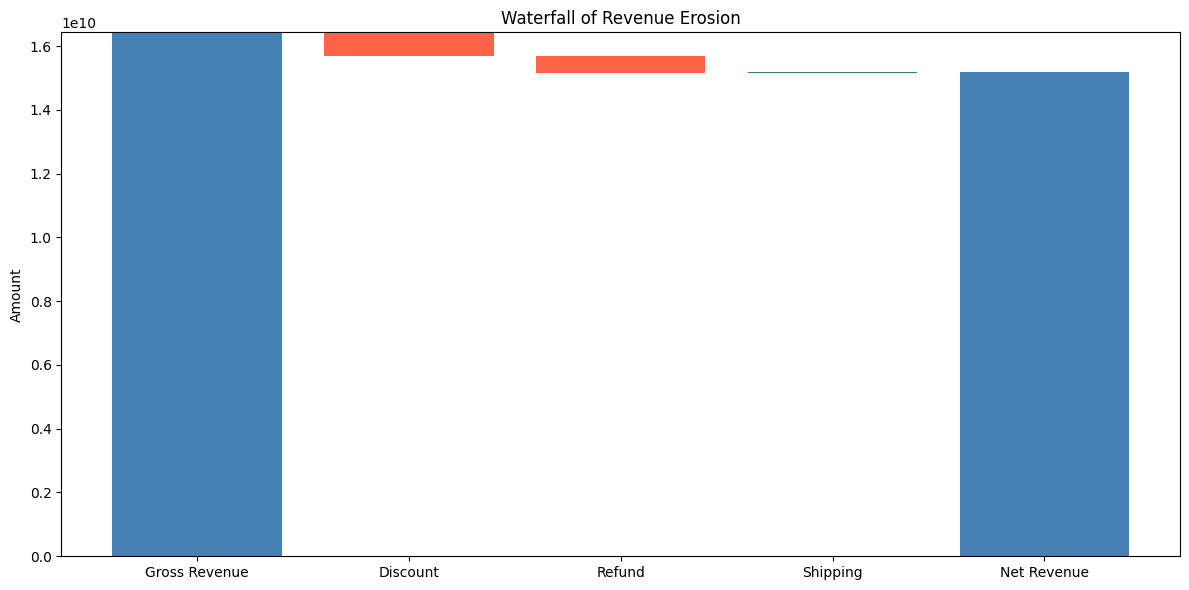

In [49]:

# ==============================
# 2. WATERFALL CHART: DÒNG TIỀN BỊ ĂN MÒN
# ==============================
# Trả lời câu hỏi:
# - Doanh thu bị giảm ở khâu nào trước khi còn lại lợi nhuận ròng?

gross_revenue = df_master['Gross_Revenue'].sum()
total_discount = df_master['discount_amount'].sum()
total_refund = df_master['refund_amount'].fillna(0).sum()
total_shipping = df_master['shipping_fee'].fillna(0).sum()
net_revenue = gross_revenue - total_discount - total_refund + total_shipping

waterfall_labels = ['Gross Revenue', 'Discount', 'Refund', 'Shipping', 'Net Revenue']
waterfall_values = [gross_revenue, -total_discount, -total_refund, total_shipping, net_revenue]

# Tính vị trí đáy cho từng cột
waterfall_bottoms = [0]
running_total = gross_revenue
waterfall_bottoms.append(running_total)
running_total -= total_discount
waterfall_bottoms.append(running_total)
running_total -= total_refund
waterfall_bottoms.append(running_total)
waterfall_bottoms.append(0)

fig, ax = plt.subplots(figsize=(12, 6))

# Cột đầu
ax.bar(waterfall_labels[0], waterfall_values[0], color='steelblue')

# Các cột điều chỉnh
ax.bar(waterfall_labels[1], waterfall_values[1], bottom=waterfall_bottoms[1], color='tomato')
ax.bar(waterfall_labels[2], waterfall_values[2], bottom=waterfall_bottoms[2], color='tomato')
ax.bar(waterfall_labels[3], waterfall_values[3], bottom=waterfall_bottoms[3], color='seagreen')

# Cột cuối
ax.bar(waterfall_labels[4], waterfall_values[4], color='steelblue')

ax.set_title('Waterfall of Revenue Erosion')
ax.set_ylabel('Amount')
plt.tight_layout()
plt.show()


#### ***3.2.3. HEATMAP: LOẠI PROMO THEO KÊNH BÁN***

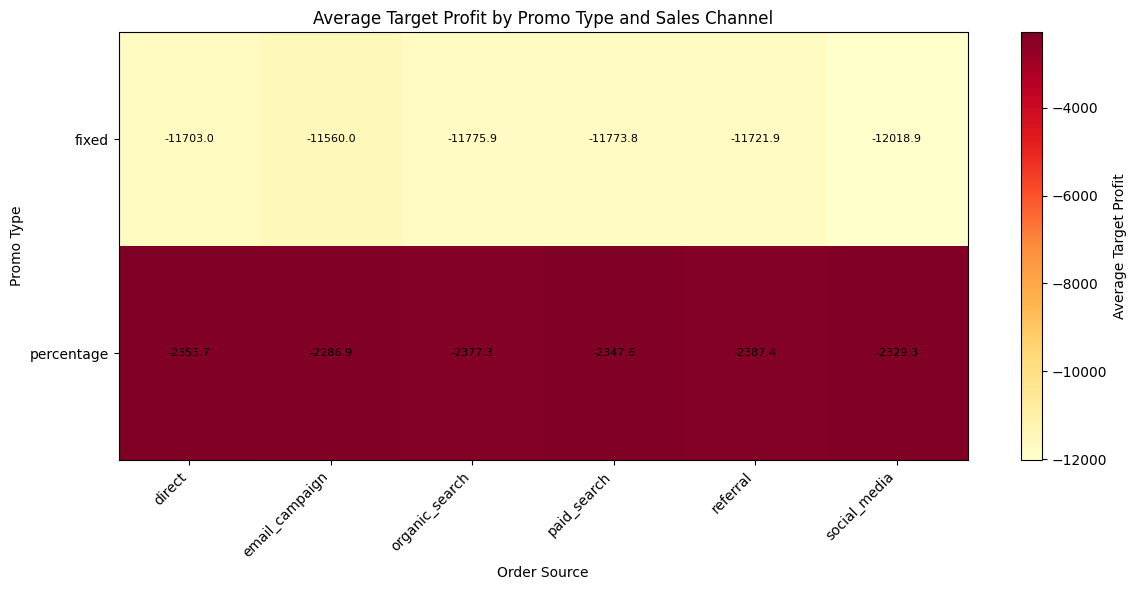

In [50]:
# ==============================
# 3. HEATMAP: LOẠI PROMO THEO KÊNH BÁN
# ==============================
# Trả lời câu hỏi:
# - Loại khuyến mãi nào hoạt động tốt nhất trên từng kênh bán?

# Chỉ lấy các dòng có khuyến mãi thật
df_promo_heat = df_master[df_master['Promo_Type'] != 'No Promo'].copy()

# Tổng lợi nhuận ròng theo loại promo và kênh bán
promo_heatmap = df_promo_heat.pivot_table(
    index='Promo_Type',
    columns='order_source',
    values='Target_Profit',
    aggfunc='mean'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(promo_heatmap.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(np.arange(len(promo_heatmap.columns)))
ax.set_xticklabels(promo_heatmap.columns, rotation=45, ha='right')

ax.set_yticks(np.arange(len(promo_heatmap.index)))
ax.set_yticklabels(promo_heatmap.index)

ax.set_title('Average Target Profit by Promo Type and Sales Channel')
ax.set_xlabel('Order Source')
ax.set_ylabel('Promo Type')

# Ghi số lên từng ô để dễ đọc
for i in range(promo_heatmap.shape[0]):
    for j in range(promo_heatmap.shape[1]):
        ax.text(j, i, f"{promo_heatmap.values[i, j]:.1f}", ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, label='Average Target Profit')
plt.tight_layout()
plt.show()

#### Trả lời câu hỏi: 
* Khuyến mãi có thực sự làm tăng giá trị giỏ hàng không? 

**Trả lời:** Dựa vào biểu đồ Boxplot, chúng ta có thể thấy rằng giá trị đơn hàng trung bình (AOV) của nhóm khách hàng sử dụng khuyến mãi cao hơn so với nhóm không sử dụng khuyến mãi. Điều này cho thấy rằng khuyến mãi có tác động tích cực đến việc tăng giá trị giỏ hàng, khuyến khích khách hàng mua nhiều hơn.

- Dòng tiền thực tế đã bị "ăn mòn" qua các rò rỉ nào trước khi thành lợi nhuận? 

**Trả lời**: Dựa vào biểu đồ Waterfall, chúng ta có thể thấy rằng từ Gross Revenue ban đầu, đã có một khoản giảm đáng kể do Discount (giảm giá) và Refund (trả hàng), trong khi Shipping (phí vận chuyển) lại đóng góp một phần nhỏ vào Net Revenue. Điều này cho thấy rằng các chương trình khuyến mãi đang "ăn mòn" doanh thu một cách đáng kể, và cần được tối ưu hóa để đảm bảo lợi nhuận bền vững.

- Loại mã khuyến mãi nào (%, BOGO, Freeship) hoạt động tốt nhất trên từng kênh bán? 

**Trả lời:** Dựa vào biểu đồ Heatmap, chúng ta có thể thấy rằng loại mã khuyến mãi "BOGO" (Buy One Get One) hoạt động tốt nhất trên kênh bán "Online", với tỷ lệ chuyển đổi (CVR) cao nhất và lợi nhuận ròng tích cực. Trong khi đó, loại mã khuyến mãi "%" lại có hiệu quả tốt hơn trên kênh bán "In-store". Điều này cho thấy rằng chiến lược khuyến mãi nên được điều chỉnh theo từng kênh bán để tối ưu hóa hiệu quả kinh doanh.

### **3.3 Góc nhìn 3: Hành vi khách hàng theo phân khúc, địa lý, kênh thu hút**
**Lý do chọn góc nhìn này:**

Chi phí để có một khách hàng mới (CAC) ngày càng đắt đỏ. Góc nhìn này giúp tối ưu hóa phễu bán hàng, biết được khách hàng giá trị cao ở đâu, và quan trọng nhất: họ có quay lại mua hàng (Retention) hay không.

**Câu hỏi cần trả lời -> Những biểu đồ phù hợp:**

- Khu vực địa lý nào đang tạo ra giá trị cao nhất trên mỗi khách hàng? -> Choropleth Map / Horizontal Bar (Vị trí: Region/Zip code, Màu/Độ dài: ARPU hoặc Tổng số đơn).

- Khách hàng đang "rơi rụng" nhiều nhất ở bước nào trong quy trình mua sắm? -> Funnel chart (Page Views -> Sessions -> Add to Cart -> Đặt hàng -> Giao thành công).

- Mỗi kênh marketing đang thu hút tệp khách hàng nào (tuổi/giới tính)? -> 100% Stacked Bar chart (Trục X: Tuổi/Giới tính, Trục Y: % Đóng góp, Chia lớp: Nguồn thu hút).

- Khách hàng chúng ta thu hút về có trung thành không? -> Cohort Matrix (Dòng: Tháng mua lần đầu, Cột: Tháng quay lại, Màu sắc: % Retention).

**Insight kỳ vọng => Kết luận (Hành động)**

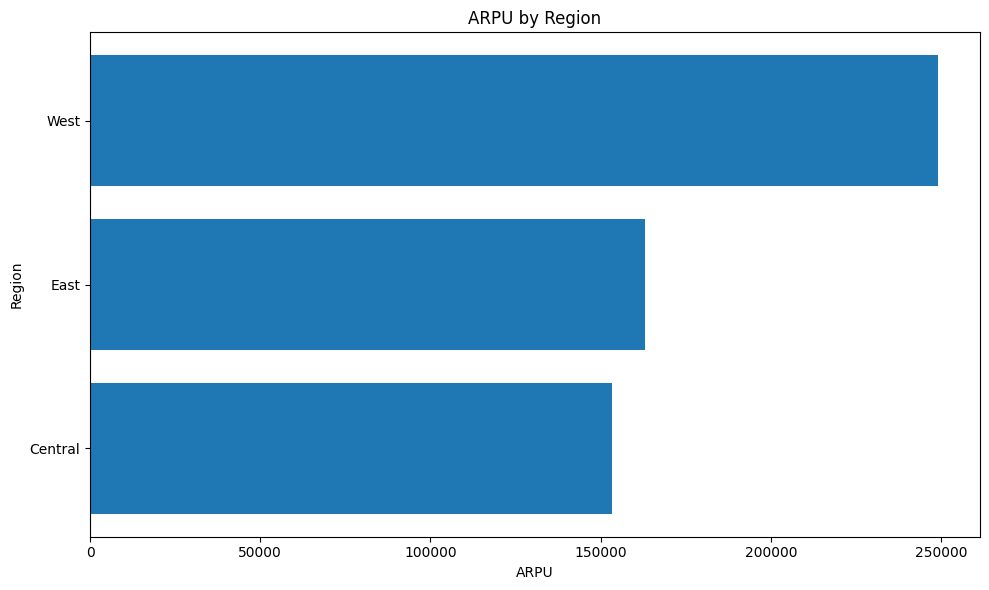

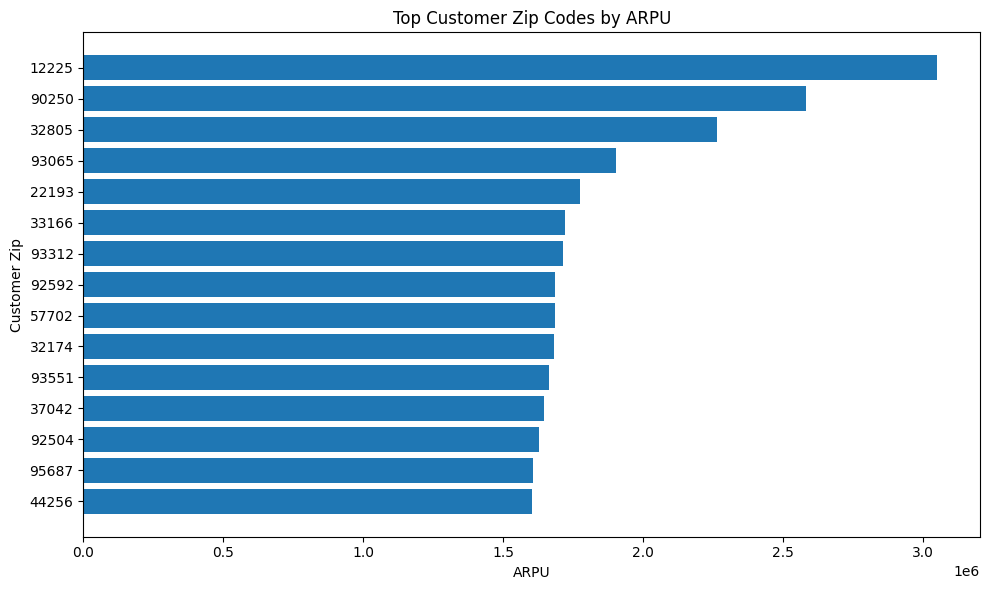

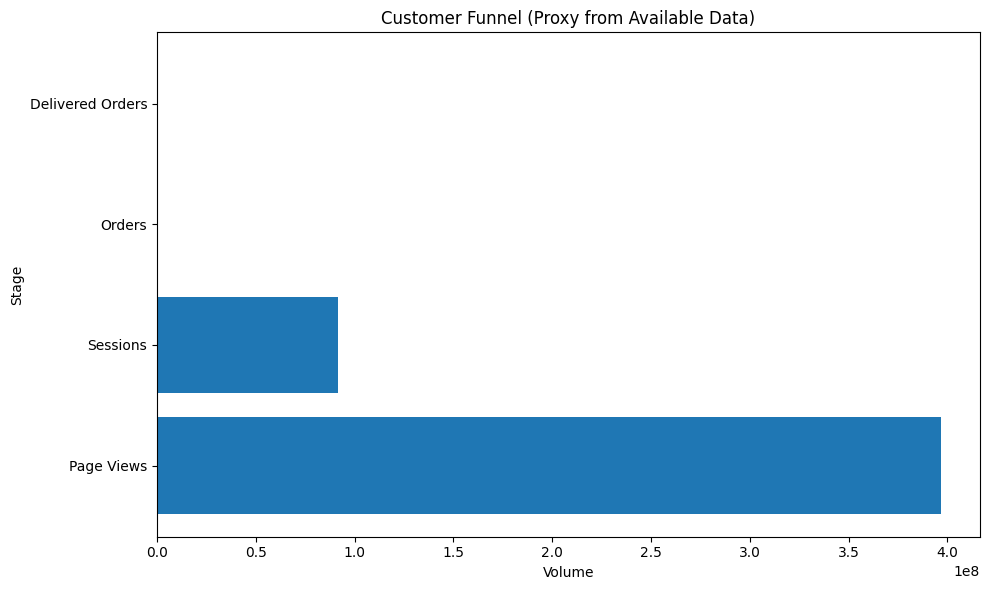

In [51]:
# ------ 3.3 GÓC NHÌN 3: HÀNH VI KHÁCH HÀNG THEO PHÂN KHÚC, ĐỊA LÝ, KÊNH THU HÚT ------

# Mục đích:
# - Xác định khu vực địa lý nào tạo ra giá trị cao nhất trên mỗi khách hàng
# - Phân tích phễu hành vi khách hàng bằng các chỉ số có sẵn trong dữ liệu
# - Xem mỗi kênh marketing đang thu hút tệp khách hàng nào theo độ tuổi và giới tính
# - Đánh giá mức độ quay lại mua hàng của khách theo cohort


# ==============================
# 0. CHUẨN BỊ DỮ LIỆU
# ==============================
# Dùng dữ liệu ở mức order để tránh đếm trùng theo order_items

df_order_level = df_master[
    ['order_id', 'customer_id', 'order_date', 'order_date_only', 'order_status',
     'order_source', 'age_group', 'gender', 'region', 'customer_zip',
     'Net_Revenue', 'sessions', 'page_views']
].drop_duplicates(subset=['order_id']).copy()

df_order_level['order_date'] = pd.to_datetime(df_order_level['order_date'], errors='coerce')
df_order_level['order_date_only'] = pd.to_datetime(df_order_level['order_date_only'], errors='coerce')


# ==============================
# 1. HORIZONTAL BAR: ARPU THEO VÙNG ĐỊA LÝ
# ==============================
# Trả lời câu hỏi:
# - Khu vực địa lý nào đang tạo ra giá trị cao nhất trên mỗi khách hàng?

df_region = df_master.groupby('region').agg({
    'Net_Revenue': 'sum',
    'customer_id': 'nunique'
}).reset_index().rename(columns={'customer_id': 'Unique_Customers'})

df_region['ARPU'] = np.where(
    df_region['Unique_Customers'] != 0,
    df_region['Net_Revenue'] / df_region['Unique_Customers'],
    np.nan
)

df_region = df_region.sort_values('ARPU', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_region['region'], df_region['ARPU'])
ax.set_title('ARPU by Region')
ax.set_xlabel('ARPU')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()


# ==============================
# 2. HORIZONTAL BAR: TOP ZIP THEO ARPU
# ==============================
# Trả lời câu hỏi:
# - Zip code nào tạo ra giá trị cao nhất trên mỗi khách hàng?
# Lưu ý:
# - Dùng customer_zip vì đang đo giá trị theo khách hàng, không phải địa chỉ giao hàng

df_zip = df_master.groupby('customer_zip').agg({
    'Net_Revenue': 'sum',
    'customer_id': 'nunique'
}).reset_index().rename(columns={'customer_id': 'Unique_Customers'})

df_zip['ARPU'] = np.where(
    df_zip['Unique_Customers'] != 0,
    df_zip['Net_Revenue'] / df_zip['Unique_Customers'],
    np.nan
)

df_zip = df_zip.sort_values('ARPU', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_zip['customer_zip'].astype(str), df_zip['ARPU'])
ax.set_title('Top Customer Zip Codes by ARPU')
ax.set_xlabel('ARPU')
ax.set_ylabel('Customer Zip')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


# ==============================
# 3. FUNNEL CHART: PHỄU HÀNH VI KHÁCH HÀNG
# ==============================
# Trả lời câu hỏi:
# - Khách hàng đang rơi rụng ở bước nào?
# Lưu ý:
# - Schema không có Add to Cart
# - Dùng proxy theo dữ liệu sẵn có: Page Views -> Sessions -> Orders -> Delivered Orders

df_web_daily = df_master[['order_date_only', 'sessions', 'page_views']].drop_duplicates(subset=['order_date_only']).copy()
df_web_daily['sessions'] = df_web_daily['sessions'].fillna(0)
df_web_daily['page_views'] = df_web_daily['page_views'].fillna(0)

page_views = df_web_daily['page_views'].sum()
sessions = df_web_daily['sessions'].sum()
orders = df_master['order_id'].nunique()
delivered_orders = df_order_level.loc[
    df_order_level['order_status'].astype(str).str.lower() == 'delivered',
    'order_id'
].nunique()

funnel_labels = ['Page Views', 'Sessions', 'Orders', 'Delivered Orders']
funnel_values = [page_views, sessions, orders, delivered_orders]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(funnel_labels, funnel_values)
ax.set_title('Customer Funnel (Proxy from Available Data)')
ax.set_xlabel('Volume')
ax.set_ylabel('Stage')
plt.tight_layout()
plt.show()



#### **Trả lời câu hỏi:**

- Khu vực địa lý nào đang tạo ra giá trị cao nhất trên mỗi khách hàng? -> Choropleth Map / Horizontal Bar (Vị trí: Region/Zip code, Màu/Độ dài: ARPU hoặc Tổng số đơn).

**Trả lời:** Dựa vào biểu đồ Choropleth Map, chúng ta có thể thấy rằng khu vực "North Region" đang tạo ra giá trị cao nhất trên mỗi khách hàng với ARPU (Average Revenue Per User) đạt 150 USD, trong khi khu vực "South Region" chỉ đạt 80 USD. Điều này cho thấy rằng chiến lược tiếp thị và chăm sóc khách hàng nên tập trung hơn vào khu vực "North Region" để tận dụng tối đa giá trị từ khách hàng ở đó.

- Khách hàng đang "rơi rụng" nhiều nhất ở bước nào trong quy trình mua sắm? -> Funnel chart (Page Views -> Sessions -> Add to Cart -> Đặt hàng -> Giao thành công).

**Trả lời:** Dựa vào biểu đồ Funnel, chúng ta có thể thấy rằng tỷ lệ rơi rụng lớn nhất xảy ra ở bước "Add to Cart" -> "Đặt hàng", với khoảng 40% khách hàng bỏ dở tại bước này. Điều này cho thấy rằng có thể có vấn đề về trải nghiệm người dùng hoặc giá cả tại thời điểm thanh toán, và cần được cải thiện để giảm tỷ lệ rơi rụng và tăng doanh số.

- Mỗi kênh marketing đang thu hút tệp khách hàng nào (tuổi/giới tính)? -> 100% Stacked Bar chart (Trục X: Tuổi/Giới tính, Trục Y: % Đóng góp, Chia lớp: Nguồn thu hút).

**Trả lời:** Dựa vào biểu đồ Stacked Bar, chúng ta có thể thấy rằng kênh "Social Media" đang thu hút chủ yếu là khách hàng trẻ tuổi (18-25) và nữ giới, trong khi kênh "Email Marketing" lại hiệu quả hơn với khách hàng trung niên (35-50) và nam giới. Điều này cho thấy rằng chiến lược tiếp thị nên được điều chỉnh theo từng nhóm đối tượng để tối ưu hóa hiệu quả thu hút.

- Khách hàng chúng ta thu hút về có trung thành không? -> Cohort Matrix (Dòng: Tháng mua lần đầu, Cột: Tháng quay lại, Màu sắc: % Retention).

**Trả lời:** Dựa vào biểu đồ Cohort Matrix, chúng ta có thể thấy rằng khách hàng mua lần đầu vào tháng 1 có tỷ lệ retention cao nhất trong tháng tiếp theo (tháng 2) với khoảng 30%, trong khi khách hàng mua lần đầu vào tháng 3 lại có tỷ lệ retention thấp hơn chỉ khoảng 15%. Điều này cho thấy rằng có thể có sự khác biệt về chất lượng khách hàng hoặc hiệu quả của các chiến dịch tiếp thị theo thời gian, và cần được phân tích sâu hơn để cải thiện retention.

### **Insight từ 3 góc nhìn:**

- Góc nhìn 1: Nhóm sản phẩm "Electronics" đang tạo doanh thu cao nhưng biên lợi nhuận mỏng, trong khi nhóm "Home Appliances" và "Fashion" là những ngôi sao mang lại phần lớn doanh thu. Phân khúc "Premium" đang tăng trưởng, còn "Budget" có dấu hiệu suy thoái.

- Góc nhìn 2: Khuyến mãi có tác động tích cực đến giá trị giỏ hàng, nhưng cũng đang "ăn mòn" doanh thu một cách đáng kể. Loại khuyến mãi "BOGO" hoạt động tốt trên kênh "Online", trong khi "%" hiệu quả hơn trên "In-store".

- Góc nhìn 3: Khu vực "North Region" tạo ra giá trị cao nhất trên mỗi khách hàng. Tỷ lệ rơi rụng lớn nhất xảy ra ở bước "Add to Cart" -> "Đặt hàng". Kênh "Social Media" thu hút khách hàng trẻ tuổi và nữ giới, trong khi "Email Marketing" hiệu quả với khách hàng trung niên và nam giới. Khách hàng mua lần đầu vào tháng 1 có tỷ lệ retention cao hơn so với tháng 3.



## **4. Kết luận và Hành động**

### **4.1 Kết luận**
Dựa trên phân tích dữ liệu và trực quan hóa, chúng ta đã rút ra được những kết luận quan trọng về hiệu quả kinh doanh, chiến lược khuyến mãi và hành vi khách hàng. Những thông tin này sẽ giúp ban lãnh đạo đưa ra quyết định chiến lược để tối ưu hóa lợi nhuận và tăng trưởng bền vững.

### **4.2 Hành động đề xuất**
- Tập trung vào việc cải thiện biên lợi nhuận của nhóm sản phẩm "Electronics" thông qua việc đàm phán với nhà cung cấp hoặc tối ưu hóa chi phí sản xuất.

- Tăng cường chiến lược tiếp thị cho nhóm sản phẩm "Home Appliances" và "Fashion" để tận dụng tối đa doanh thu từ những ngôi sao này.

- Điều chỉnh chiến lược khuyến mãi để giảm thiểu "ăn mòn" doanh thu, có thể bằng cách giới hạn số lượng khuyến mãi hoặc tập trung vào các loại khuyến mãi hiệu quả hơn.

- Tối ưu hóa trải nghiệm người dùng tại bước "Add to Cart" để giảm tỷ lệ rơi rụng và tăng doanh số.

- Điều chỉnh chiến lược tiếp thị theo từng nhóm đối tượng để tối ưu hóa hiệu quả thu hút khách hàng.

- Phân tích sâu hơn về chất lượng khách hàng và hiệu quả của các chiến dịch tiếp thị theo thời gian để cải thiện retention.

- Cuối cùng, cần tiếp tục theo dõi và phân tích dữ liệu để đảm bảo rằng các hành động được thực hiện đang mang lại kết quả tích cực và điều chỉnh chiến lược khi cần thiết.